### Your name:

<pre> JU ZHANG</pre>

### Collaborators:

<pre> NONE </pre>

## Assignment for Module 6

In this assignment you will continue working with the housing price per district from the previous module assignment, this time training SVM models, both for regression and classification.

#### Getting the data for the assignment (similar to the notebook from chapter 2 of Hands-On...)

In [85]:
import os
import tarfile
from six.moves import urllib

DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml/master/"
HOUSING_PATH = os.path.join("datasets_assignment_6", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    if not os.path.isdir(housing_path):
        os.makedirs(housing_path)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()

In [86]:
fetch_housing_data()

In [87]:
import pandas as pd

def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

In [88]:
housing = load_housing_data()

### Fix the categories in the categorical variable

In [89]:
d = {'<1H OCEAN':'LESS_1H_OCEAN', 'INLAND':'INLAND', 'ISLAND':'ISLAND', 'NEAR BAY':'NEAR_BAY', 'NEAR OCEAN':'NEAR_OCEAN'}
housing['ocean_proximity'] = housing['ocean_proximity'].map(lambda s: d[s])

### Add 2 more features

In [90]:
housing["rooms_per_household"] = housing["total_rooms"]/housing["households"]
housing["population_per_household"]=housing["population"]/housing["households"]
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR_BAY,6.984127,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR_BAY,6.238137,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR_BAY,8.288136,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR_BAY,5.817352,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR_BAY,6.281853,2.181467


### Fix missing data

In [91]:
median = housing["total_bedrooms"].median()
housing["total_bedrooms"] = housing["total_bedrooms"].fillna(median)

### Create dummy variables based on the categorical variable

In [92]:
one_hot = pd.get_dummies(housing['ocean_proximity'])
housing = housing.drop('ocean_proximity', axis=1)
housing = housing.join(one_hot)
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,population_per_household,INLAND,ISLAND,LESS_1H_OCEAN,NEAR_BAY,NEAR_OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,6.984127,2.555556,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,6.238137,2.109842,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,8.288136,2.802260,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,5.817352,2.547945,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,6.281853,2.181467,False,False,False,True,False


### Check the data

In [93]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   longitude                 20640 non-null  float64
 1   latitude                  20640 non-null  float64
 2   housing_median_age        20640 non-null  float64
 3   total_rooms               20640 non-null  float64
 4   total_bedrooms            20640 non-null  float64
 5   population                20640 non-null  float64
 6   households                20640 non-null  float64
 7   median_income             20640 non-null  float64
 8   median_house_value        20640 non-null  float64
 9   rooms_per_household       20640 non-null  float64
 10  population_per_household  20640 non-null  float64
 11  INLAND                    20640 non-null  bool   
 12  ISLAND                    20640 non-null  bool   
 13  LESS_1H_OCEAN             20640 non-null  bool   
 14  NEAR_BAY         

### Partition into train and test

Use train_test_split from sklearn.model_selection to partition the dataset into 70% for training and 30% for testing.

You can use the 70% for training set as both training and validation by using cross-validation.


In [94]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing, test_size=0.3, random_state=42)

### Features

In [95]:
# ** take out the target variable and features
target = 'median_house_value'
features = list(train_set.columns)
features = [f for f in features if f!=target]

In [96]:
X_tr = train_set[features]
y_tr = train_set[[target]]

X_te = test_set[features]
y_te = test_set[[target]]

### Scaling features

Similarly, use StandardScaler from sklearn.preprocessing to normalize the training and testing data, using the training data

In [100]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_tr)
X_tr = scaler.transform(X_tr)
X_te = scaler.transform(X_te)

#### Comparing models

In [20]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
import numpy as np

def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())

### Linear regression on original features (no transformations) --- benchmark

In [102]:
from sklearn.linear_model import LinearRegression
lin_scores = cross_val_score(LinearRegression(), train_set[features], train_set[target], scoring="neg_mean_squared_error", cv=4)
lin_rmse_scores = np.sqrt(-lin_scores)
display_scores(lin_rmse_scores)

Scores: [70142.55721218 67456.39127204 67318.3258893  70866.26065275]
Mean: 68945.88375656867


### 1. Support Vector Machines for Regression

#### (a) In this exercise your goal is to tune SVR with FBR kernel, and make the average score mean_squared_error over 3-folds (cv=3) below 58000. 

You are encouraged to try optimizing any of the hyper-parameters of SVR

See http://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html for more details

However, as a hint, you can focus on C and gamma. 

Hint 2: if when you try different values for a hyper-parameter, the optimal models corresponds to one of the extreme values in your range, that probably means you can keep improving your solution by considering values beyond the current range.



In [103]:
from sklearn.svm import SVR

C_vals = [300000, 500000, 1000000]
gamma_vals = [0.1, 0.2, 0.3]

param_grid = [{'C': C_vals, 'gamma': gamma_vals}]
grid_search_rbf = GridSearchCV(SVR(kernel='rbf'), param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_rbf.fit(X_tr, np.ravel(y_tr))

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVR()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [300000, 500000, ...], 'gamma': [0.1, 0.2, ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fo

In [106]:
print(grid_search_rbf.best_params_)
print(np.sqrt(-grid_search_rbf.best_score_))

{'C': 500000, 'gamma': 0.2}
55149.378893901725


### Performance on Test Set

In [107]:
from sklearn.metrics import mean_squared_error

final_model = grid_search_rbf.best_estimator_   ## THIS SHOULD BE THE BEST GRID_SEARCH ##

y_te_estimation = final_model.predict(X_te)

final_mse = mean_squared_error(y_te, y_te_estimation)
final_rmse = np.sqrt(final_mse)
print(final_rmse)

53877.57961629018


### 2. SVM for Classification

Now we transform the continuous target into a binary variable, indicating whether or not the price is above the average $179700


In [108]:
from sklearn.metrics import accuracy_score

In [109]:
np.median(housing[['median_house_value']])

np.float64(179700.0)

#### Binary target variable

In [110]:
y_tr_b = 1*np.ravel(y_tr>=179700.0)
y_te_b = 1*np.ravel(y_te>=179700.0)

In [115]:
# ** validate the binary labels
print(y_tr_b)
print(y_te_b)

[1 0 1 ... 1 1 1]
[0 0 1 ... 1 0 1]


#### Linear SVM for classification

In [119]:
from sklearn.svm import LinearSVC
X_tr.shape

(14448, 15)

In [117]:
lin_clf = LinearSVC(random_state=42)
lin_clf.fit(X_tr, y_tr_b)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [118]:
y_pred = lin_clf.predict(X_tr)
accuracy_score(y_tr_b, y_pred)

0.8385243632336655

### (a) Does SVC (with default hyper-parameters) improve the performance of the linear SVM?

##### Answer of a

In [120]:
from sklearn.svm import SVC

In [137]:
# ** use default SVC with RBF kernel to train the model and evaluate the training and test accuracy
svc_clf = SVC()      # ** default SVC with RBF kernel
svc_clf.fit(X_tr, y_tr_b)

svc_y_pred_train = svc_clf.predict(X_tr)
svc_y_pred_test = svc_clf.predict(X_te)

# print("LinearSVC training accuracy:", accuracy_score(y_tr_b, y_pred))
# print("Default SVC training accuracy:", accuracy_score(y_tr_b, svc_y_pred_train))
# print("Default SVC test accuracy:", accuracy_score(y_te_b, svc_y_pred_test))
# print("Yes. The default SVC improves over the linear SVM on the training set.")

# ** LinearSVC training accuracy
L_svc_train_acc = accuracy_score(y_tr_b, y_pred)
print("LinearSVC training accuracy:", L_svc_train_acc)

# ** Default SVC training accuracy
D_svc_train_acc = accuracy_score(y_tr_b, svc_y_pred_train)  
print("Default SVC training accuracy:", D_svc_train_acc)

# ** train conclusion
if D_svc_train_acc > L_svc_train_acc:
    print("Yes. The default SVC improves over the linear SVM on the training set.")
else:    
    print("No. The default SVC does not improve over the linear SVM on the training set.")

print("=="*50)

# ** linear SVC test accuracy
y_te_pred = lin_clf.predict(X_te)
L_svc_test_acc = accuracy_score(y_te_b, y_te_pred)
print("LinearSVC test accuracy:", L_svc_test_acc)

# ** Default SVC test accuracy
D_svc_test_acc = accuracy_score(y_te_b, svc_y_pred_test)
print("Default SVC test accuracy:", D_svc_test_acc)

# ** test conclusion
if D_svc_test_acc > L_svc_test_acc:
    print("Yes. The default SVC improves over the linear SVM on the test set.")
else:    
    print("No. The default SVC does not improve over the linear SVM on the test set.")


LinearSVC training accuracy: 0.8385243632336655
Default SVC training accuracy: 0.866140642303433
Yes. The default SVC improves over the linear SVM on the training set.
LinearSVC test accuracy: 0.8394702842377261
Default SVC test accuracy: 0.8624031007751938
Yes. The default SVC improves over the linear SVM on the test set.


##### Based on the above accuracy from LinearSVC and default SVc the default SVC improves over the linear SVM on the test set.

---

### (b) Use randomized search to tune hyper-parameters of SVC and improve its performance

##### Answer of b

In [33]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import reciprocal, uniform

In [136]:
# ** use RandomizedSearchCV to tune the hyperparameters of SVC and evaluate the test accuracy of the tuned SVC
# ** set the hyperparameter distributions for C and gamma
param_distributions = {
    'C': reciprocal(1, 1000),
    'gamma': reciprocal(0.001, 1)
}

rnd_search_svc = RandomizedSearchCV(
    SVC(kernel='rbf'),
    param_distributions=param_distributions,
    n_iter=20,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
rnd_search_svc.fit(X_tr, y_tr_b)

best_svc = rnd_search_svc.best_estimator_
svc_tuned_y_pred = best_svc.predict(X_te)

# ** print the best hyperparameters, best score, and test accuracy of the tuned SVC

print("Best hyperparameters:", rnd_search_svc.best_params_)
print("Best cross-validation accuracy:", rnd_search_svc.best_score_)
print("Tuned SVC test accuracy:", accuracy_score(y_te_b, svc_tuned_y_pred))

Best hyperparameters: {'C': np.float64(63.583588566762494), 'gamma': np.float64(0.13311216080736885)}
Best cross-validation accuracy: 0.8741694352159469
Tuned SVC test accuracy: 0.8777454780361758


##### Based on the accuracy get from randomized seach, which for tunned SVC there's improvement.
##### Tuned SVC test accuracy(0.8777454780361758) > Default SVC test accuracy(0.8624031007751938)


---

### (c) Train a Logistic Regression (search teh best hyper-parameters) and compare its performance with SVC 

#### Answer of c

In [139]:
from sklearn.linear_model import LogisticRegression

# ** use C as hyper-parameter to tune the logistic regression model
param_grid_logistic = [{'C': [0.01, 0.1, 1, 10, 100]}]

# ** use GridSearchCV, with cv=3
grid_search_logistic = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=42),
    param_grid_logistic,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
grid_search_logistic.fit(X_tr, y_tr_b)

best_logistic = grid_search_logistic.best_estimator_
logistic_y_pred = best_logistic.predict(X_te)

print("Best logistic regression model:", best_logistic)
print("Best logistic regression hyperparameters:", grid_search_logistic.best_params_)
print("Best logistic regression cross-validation accuracy:", grid_search_logistic.best_score_)
print("Logistic regression test accuracy:", accuracy_score(y_te_b, logistic_y_pred))
print("Tuned SVC test accuracy:", accuracy_score(y_te_b, svc_tuned_y_pred))
print("The tuned SVC performs better than logistic regression on this test set." 
      if accuracy_score(y_te_b, svc_tuned_y_pred) > accuracy_score(y_te_b, logistic_y_pred) 
    else "The tuned SVC does not perform better than logistic regression on this test set.")

Best logistic regression model: LogisticRegression(C=100, max_iter=2000, random_state=42)
Best logistic regression hyperparameters: {'C': 100}
Best logistic regression cross-validation accuracy: 0.8377630121816169
Logistic regression test accuracy: 0.8406007751937985
Tuned SVC test accuracy: 0.8777454780361758
The tuned SVC performs better than logistic regression on this test set.


##### Answer of c
The tuned SVC performs better than logistic regression on this test set.

Plot the accuracy

   mean_fit_time  std_fit_time  mean_score_time  std_score_time  param_C  \
0       0.067824      0.021828         0.002666        0.000273     0.01   
1       0.083233      0.022155         0.003024        0.000803     0.10   
2       0.072245      0.004817         0.003314        0.001085     1.00   
3       0.078786      0.022607         0.002613        0.000674    10.00   
4       0.083874      0.006060         0.002171        0.000160   100.00   

        params  split0_test_score  split1_test_score  split2_test_score  \
0  {'C': 0.01}           0.825581           0.825374           0.826620   
1   {'C': 0.1}           0.835963           0.833264           0.837625   
2     {'C': 1}           0.840116           0.835548           0.836379   
3    {'C': 10}           0.840116           0.836379           0.836171   
4   {'C': 100}           0.840324           0.836379           0.836586   

   mean_test_score  std_test_score  rank_test_score  
0         0.825858        0.000545    

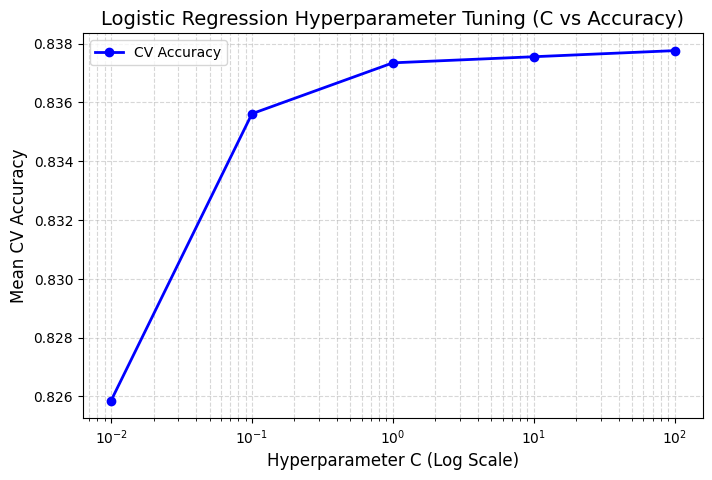

In [143]:
import matplotlib.pyplot as plt
import pandas as pd

# update result to DataFrame table
results = pd.DataFrame(grid_search_logistic.cv_results_)
print(results)
# get the C values and corresponding mean test scores from the grid search results
c_values = results['param_C'].astype(float)
scores = results['mean_test_score']

# plot
plt.figure(figsize=(8, 5))
plt.plot(c_values, scores, marker='o', linestyle='-', color='b', linewidth=2, label='CV Accuracy')

# set x scale to logarithmic
plt.xscale('log')

# plot the figure
plt.title('Logistic Regression Hyperparameter Tuning (C vs Accuracy)', fontsize=14)
plt.xlabel('Hyperparameter C (Log Scale)', fontsize=12)
plt.ylabel('Mean CV Accuracy', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5) # 添加网格线
plt.legend()

# display the plot
plt.show()